# Strategy 5: Speaker Rotation Signal

**Thesis**: The Fed's choice of *who* speaks each week signals policy intent.
A week packed with hawks implies the committee wants hawkish messaging out.

**Signal**: `hawk_ratio = n_hawks / (n_hawks + n_doves)` for the week.
If hawk\_ratio >= threshold (0.7) → pay fixed Monday morning, exit Friday close.
If hawk\_ratio <= 1-threshold (0.3) → receive fixed.

No NLP, no per-speech timing. Pure scheduling-based signal.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END = "2026-06-30"

CONSENSUS = {
    "Bowman": 1, "George": 1, "Logan": 1, "Mester": 1, "Schmid": 1,
    "Hammack": 1, "Musalem": 1, "Warsh": 1, "Barkin": 1, "Kashkari": 1,
    "Brainard": -1, "Bostic": -1, "Goolsbee": -1, "Cook": -1,
    "Daly": -1, "Kugler": -1, "Harker": -1,
    "Powell": 0, "Williams": 0, "Jefferson": 0, "Collins": 0,
    "Waller": 0, "Barr": 0,
}

FOMC_DATES = [
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]

ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

print("Config loaded.")

Config loaded.


## 1. Load ForexFactory & Build Weekly Schedule

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme

fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

# Tag each event with consensus label
fed_speak_df["speaker"] = fed_speak_df["Title"].apply(extract_speaker)
fed_speak_df["label"] = fed_speak_df["speaker"].map(CONSENSUS).fillna(0).astype(int)
fed_speak_df["speech_date"] = pd.to_datetime(fed_speak_df["Date"]).dt.date

# Build ISO week key
fed_speak_df["iso_week"] = pd.to_datetime(fed_speak_df["Date"]).dt.isocalendar().week.astype(int)
fed_speak_df["iso_year"] = pd.to_datetime(fed_speak_df["Date"]).dt.isocalendar().year.astype(int)
fed_speak_df["week_key"] = fed_speak_df["iso_year"].astype(str) + "-W" + fed_speak_df["iso_week"].astype(str).str.zfill(2)

# Aggregate per week: count hawks and doves
weekly = fed_speak_df.groupby("week_key").agg(
    n_hawks=("label", lambda x: (x == 1).sum()),
    n_doves=("label", lambda x: (x == -1).sum()),
    n_neutral=("label", lambda x: (x == 0).sum()),
    n_total=("label", "count"),
    speakers=("speaker", lambda x: list(x.unique())),
    min_date=("speech_date", "min"),
).reset_index()

# Only weeks with at least 1 hawk or dove
weekly = weekly[(weekly["n_hawks"] + weekly["n_doves"]) > 0].copy()
weekly["hawk_ratio"] = weekly["n_hawks"] / (weekly["n_hawks"] + weekly["n_doves"])

print(f"Weeks with hawk/dove speakers: {len(weekly)}")
print(f"Hawk ratio distribution:")
print(weekly["hawk_ratio"].describe().to_string())
print(f"\nSample:")
display(weekly[["week_key", "n_hawks", "n_doves", "n_neutral", "hawk_ratio", "min_date"]].tail(10))

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
Weeks with hawk/dove speakers: 194
Hawk ratio distribution:
count    194.000000
mean       0.479972
std        0.321901
min        0.000000
25%        0.250000
50%        0.500000
75%        0.666667
max        1.000000

Sample:


,week_key,n_hawks,n_doves,n_neutral,hawk_ratio,min_date
213,2026-W13,1,3,7,0.250000,2026-03-23
214,2026-W14,2,1,4,0.666667,2026-03-30
215,2026-W15,0,2,1,0.000000,2026-04-07
216,2026-W16,4,4,8,0.500000,2026-04-13
218,2026-W19,5,6,4,0.454545,2026-05-04
219,2026-W20,3,2,4,0.600000,2026-05-12
220,2026-W21,1,1,4,0.500000,2026-05-18
221,2026-W22,7,3,5,0.700000,2026-05-27
222,2026-W23,6,3,2,0.666667,2026-06-02
223,2026-W26,3,2,3,0.600000,2026-06-22


## 2. Build Weekly Trade Events

In [3]:
def is_fomc_week(date):
    for f in FOMC_DATES:
        # Check if date falls in same ISO week as FOMC
        fomc_iso = datetime.date(f.year, f.month, f.day).isocalendar()
        date_iso = date.isocalendar()
        if fomc_iso[:2] == date_iso[:2]:
            return True
    return False

def get_monday_friday(min_date):
    # Find Monday of the week containing min_date
    d = min_date
    while d.weekday() != 0:  # 0 = Monday
        d -= datetime.timedelta(days=1)
    monday = d

    # Find Friday of same week
    friday = monday + datetime.timedelta(days=4)

    # Adjust to business days
    mon_ql = ql.Date(monday.day, monday.month, monday.year)
    fri_ql = ql.Date(friday.day, friday.month, friday.year)

    if not ql_cal.isBusinessDay(mon_ql):
        mon_ql = ql_cal.advance(mon_ql, ql.Period(1, ql.Days), ql.Following)
    if not ql_cal.isBusinessDay(fri_ql):
        fri_ql = ql_cal.advance(fri_ql, ql.Period(-1, ql.Days), ql.Preceding)

    mon_date = datetime.date(mon_ql.year(), mon_ql.month(), mon_ql.dayOfMonth())
    fri_date = datetime.date(fri_ql.year(), fri_ql.month(), fri_ql.dayOfMonth())

    entry_ts = NYC_tz.localize(datetime.datetime.combine(mon_date, datetime.time(9, 30)))
    exit_ts = NYC_tz.localize(datetime.datetime.combine(fri_date, datetime.time(16, 0)))

    return entry_ts, exit_ts


# Test multiple thresholds
THRESHOLDS = [
    ("0.7/0.3", 0.7, 0.3),
    ("0.6/0.4", 0.6, 0.4),
    ("0.8/0.2", 0.8, 0.2),
]

all_strategies = {}

for label, hawk_thresh, dove_thresh in THRESHOLDS:
    events = []
    for _, row in weekly.iterrows():
        hr = row["hawk_ratio"]
        min_date = row["min_date"]

        if is_fomc_week(min_date):
            continue

        if hr >= hawk_thresh:
            direction = 1
        elif hr <= dove_thresh:
            direction = -1
        else:
            continue

        try:
            entry_ts, exit_ts = get_monday_friday(min_date)
        except:
            continue

        if entry_ts >= exit_ts:
            continue

        # Check entry date is within BT range
        if entry_ts.date() < datetime.date(2021, 1, 1) or entry_ts.date() > datetime.date(2026, 6, 30):
            continue

        events.append({
            "week_key": row["week_key"],
            "entry_ts": entry_ts,
            "exit_ts": exit_ts,
            "direction": direction,
            "direction_label": "hawk" if direction == 1 else "dove",
            "hawk_ratio": hr,
            "n_hawks": row["n_hawks"],
            "n_doves": row["n_doves"],
            "bpv": -direction * BASE_BPV,
            "tag": f"rot_{len(events)}",
        })

    # No overlap possible since these are weekly
    all_strategies[label] = events
    n_h = sum(1 for e in events if e["direction"] == 1)
    n_d = sum(1 for e in events if e["direction"] == -1)
    print(f"Threshold {label}: {len(events)} trades (hawk={n_h}, dove={n_d})")

Threshold 0.7/0.3: 88 trades (hawk=42, dove=46)
Threshold 0.6/0.4: 134 trades (hawk=66, dove=68)
Threshold 0.8/0.2: 62 trades (hawk=30, dove=32)


## 3. Run Backtests

In [4]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

def run_bt(events, name):
    if len(events) < 2:
        print(f"  {name}: too few events, skipping")
        return None
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={"direction": ev["direction"], "hawk_ratio": ev["hawk_ratio"],
                  "n_hawks": ev["n_hawks"], "n_doves": ev["n_doves"],
                  "week_key": ev["week_key"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=name, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {name}")
    bt.run()
    return bt

def extract(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["hawk_ratio"] = cl["source_query"].apply(lambda q: q.meta["hawk_ratio"])
    cl["n_hawks"] = cl["source_query"].apply(lambda q: q.meta["n_hawks"])
    cl["n_doves"] = cl["source_query"].apply(lambda q: q.meta["n_doves"])
    cl["week_key"] = cl["source_query"].apply(lambda q: q.meta["week_key"])
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["closed_at"] = pd.to_datetime(cl["closed_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

all_closed = {}
for label, events in all_strategies.items():
    print(f"\n--- Threshold {label} ---")
    bt = run_bt(events, label)
    if bt is None:
        continue
    cl = extract(bt)
    all_closed[label] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll backtests complete.")


--- Threshold 0.7/0.3 ---


  0.7/0.3:   0%|          | 0/176 [00:00<?, ?step/s]

  0.7/0.3:   1%|          | 1/176 [00:00<01:41,  1.72step/s]

  0.7/0.3:   2%|▏         | 4/176 [00:00<00:23,  7.17step/s]

  0.7/0.3:   2%|▏         | 4/176 [00:12<00:23,  7.17step/s]

...

  0.8/0.2:  94%|█████████▍| 117/124 [01:15<00:00, 25.48step/s]

  0.8/0.2:  98%|█████████▊| 121/124 [01:15<00:00, 26.32step/s]

  0.8/0.2: 100%|██████████| 124/124 [01:15<00:00, 12.92step/s]

  0.8/0.2: 100%|██████████| 124/124 [01:15<00:00,  1.63step/s]

  Closed: 61, Cum: -60.0 bps

All backtests complete.


## 4. Summary Comparison

In [5]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

rows = []
for label in all_closed:
    cl = all_closed[label]
    hawk = cl["direction"] == 1
    rows.append({
        "Threshold": label, "Trades": len(cl),
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": cl["pnl_bps"].mean(),
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    })
summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}",
    "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}", "Max DD": "{:.1f}",
    "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Threshold,Trades,Hawk / Dove,Cum bps,Avg bps,Hit Rate,Sharpe,Max DD,Hawk bps,Dove bps
0,0.7/0.3,87,42 / 45,-70.0,-0.805,48.3%,-0.24,-179.4,-8.3,-61.7
1,0.6/0.4,131,66 / 65,-8.1,-0.062,51.1%,-0.02,-131.7,+31.2,-39.3
2,0.8/0.2,61,30 / 31,-60.0,-0.983,47.5%,-0.23,-158.5,-13.4,-46.5


## 5. Equity Curves

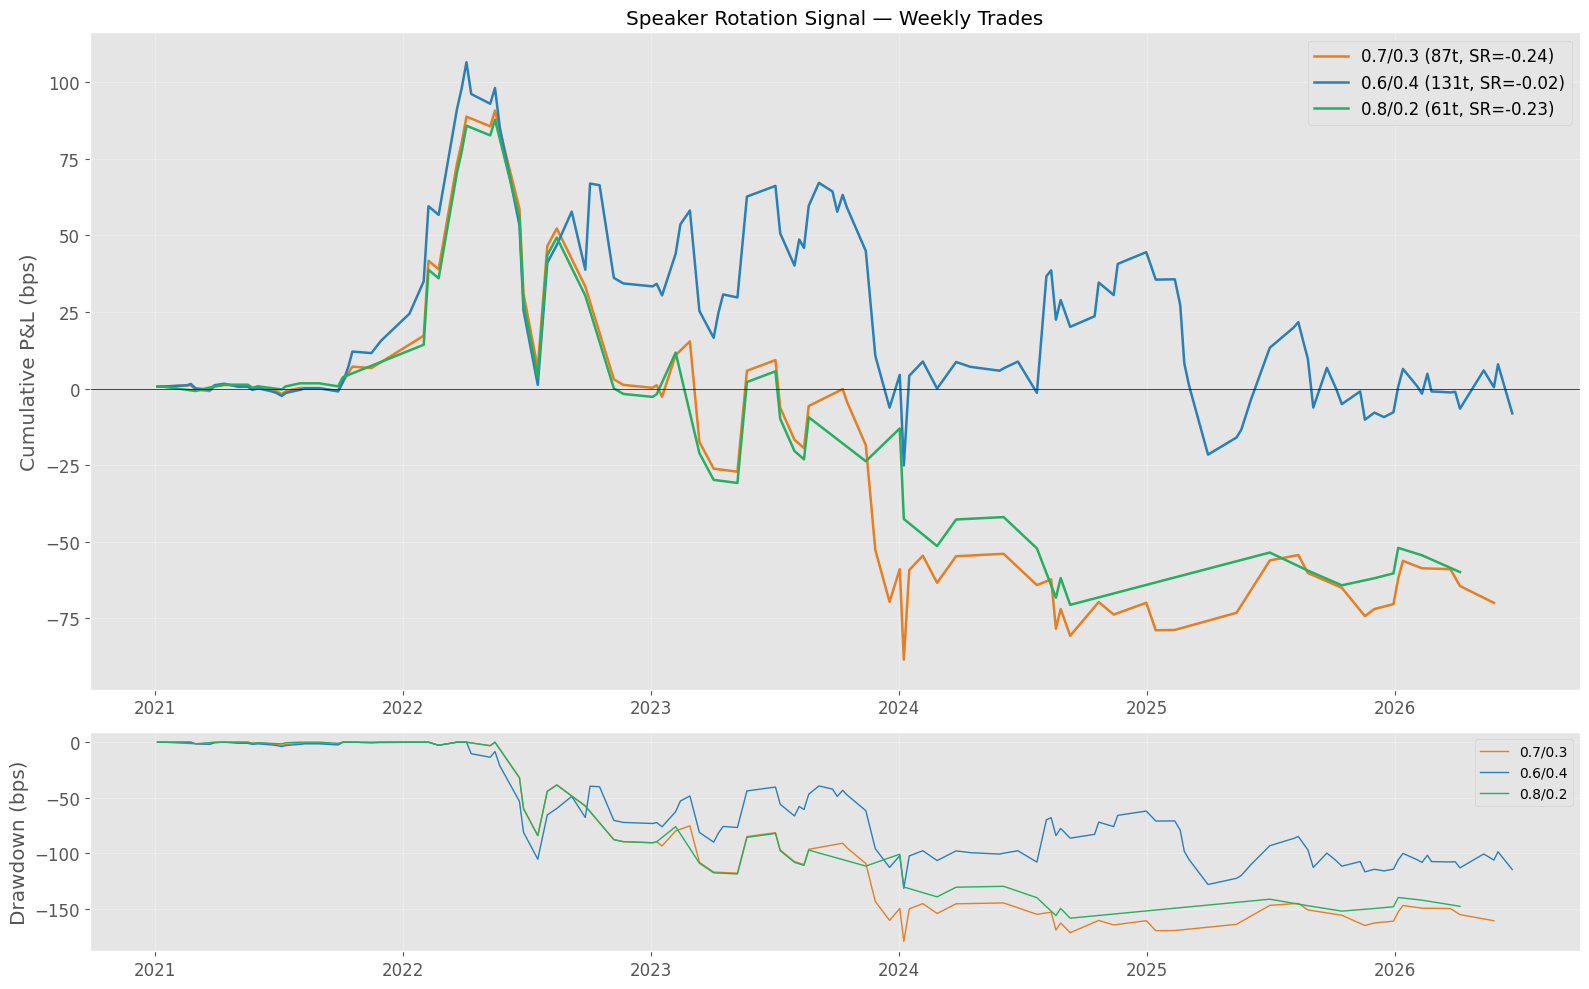

In [6]:
COLORS = {"0.7/0.3": "#e67e22", "0.6/0.4": "#2980b9", "0.8/0.2": "#27ae60"}

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for label in all_closed:
    cl = all_closed[label]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=1.8, color=COLORS.get(label, "gray"),
            label=f"{label} ({len(cl)}t, SR={_sharpe(cl):.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Speaker Rotation Signal — Weekly Trades")
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for label in all_closed:
    cl = all_closed[label]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values, lw=1, color=COLORS.get(label, "gray"), label=label)
ax2.set_ylabel("Drawdown (bps)"); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Calendar-Year Breakdown (0.7/0.3 threshold)

,trades,total_bps,avg_bps,std_bps,hit_rate,sharpe
year,,,,,,
2021,21,+6.7,+0.318,1.48,47.6%,0.98
2022,16,-5.5,-0.342,22.15,50.0%,-0.06
2023,19,-70.9,-3.730,15.76,36.8%,-1.03
2024,15,-0.3,-0.020,13.79,60.0%,-0.01
2025,10,-0.4,-0.044,7.88,60.0%,-0.02
2026,6,+0.4,+0.069,5.82,33.3%,0.03


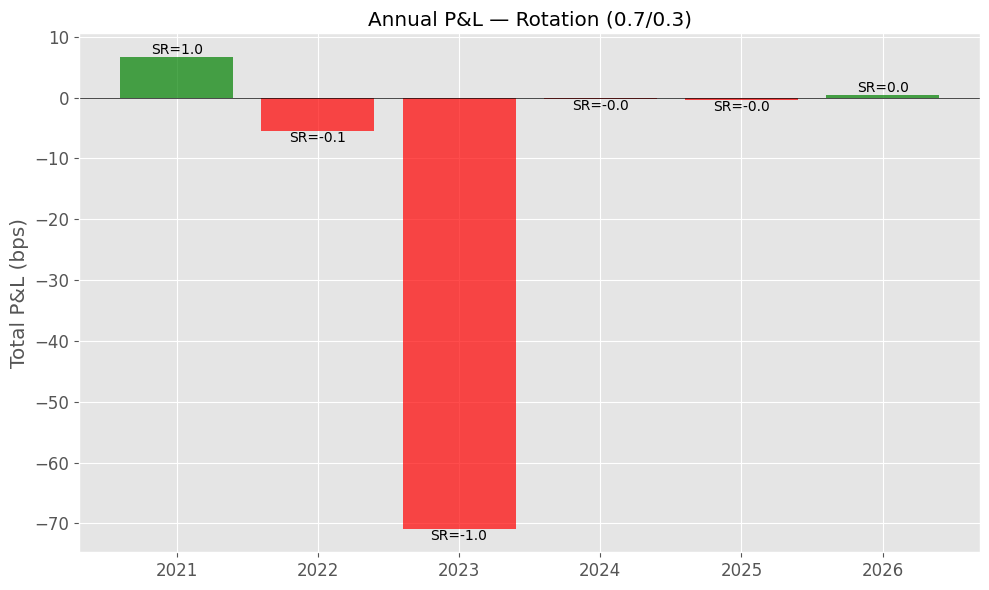

In [7]:
# Use primary threshold
primary = "0.7/0.3"
if primary in all_closed:
    cl = all_closed[primary]
    yr_stats = cl.groupby("year").agg(
        trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"), std_bps=("pnl_bps", "std"),
        hit_rate=("profitable", "mean"))
    yr_stats["sharpe"] = (yr_stats["avg_bps"] / yr_stats["std_bps"]) * np.sqrt(yr_stats["trades"])
    display(yr_stats.style.format({
        "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "std_bps": "{:.2f}",
        "hit_rate": "{:.1%}", "sharpe": "{:.2f}"}))

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["green" if x > 0 else "red" for x in yr_stats["total_bps"]]
    ax.bar(yr_stats.index.astype(str), yr_stats["total_bps"], color=colors, alpha=0.7)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("Total P&L (bps)")
    ax.set_title(f"Annual P&L — Rotation ({primary})")
    for i, (yr, row) in enumerate(yr_stats.iterrows()):
        ax.text(i, row["total_bps"], f"SR={row['sharpe']:.1f}", ha="center",
                va="bottom" if row["total_bps"] >= 0 else "top", fontsize=10)
    plt.tight_layout(); plt.show()

## 7. Hawk Ratio Analysis

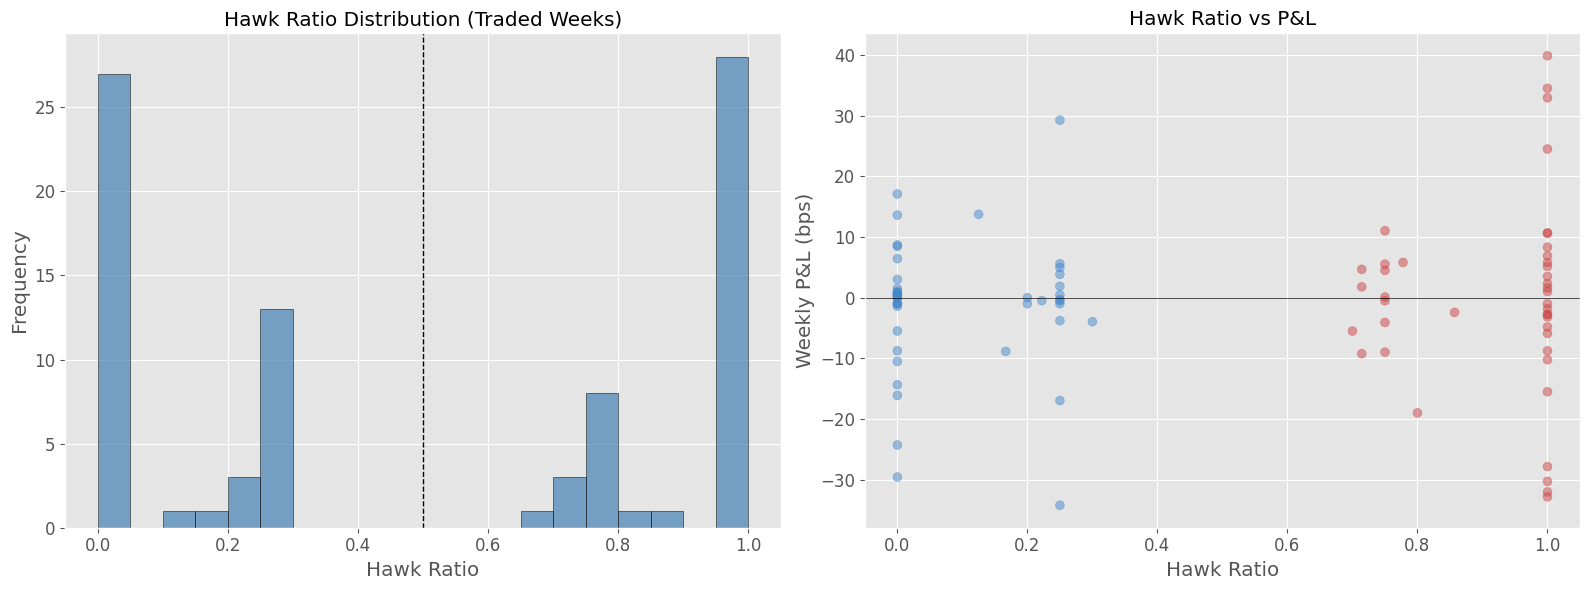

In [8]:
if primary in all_closed:
    cl = all_closed[primary]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Histogram of hawk_ratio for traded weeks
    ax = axes[0]
    ax.hist(cl["hawk_ratio"], bins=20, alpha=0.7, color="steelblue", edgecolor="black")
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set_xlabel("Hawk Ratio"); ax.set_ylabel("Frequency")
    ax.set_title("Hawk Ratio Distribution (Traded Weeks)")

    # Scatter: hawk_ratio vs weekly P&L
    ax2 = axes[1]
    colors_sc = ["#cc4444" if d == 1 else "#4488cc" for d in cl["direction"]]
    ax2.scatter(cl["hawk_ratio"], cl["pnl_bps"], alpha=0.5, c=colors_sc, s=40)
    ax2.axhline(0, color="k", lw=0.5)
    ax2.set_xlabel("Hawk Ratio"); ax2.set_ylabel("Weekly P&L (bps)")
    ax2.set_title("Hawk Ratio vs P&L")

    plt.tight_layout(); plt.show()

## 8. Hawk vs Dove Split

,trades,total_bps,avg_bps,hit_rate
direction_label,,,,
dove,45,-61.7,-1.371,46.7%
hawk,42,-8.3,-0.198,50.0%


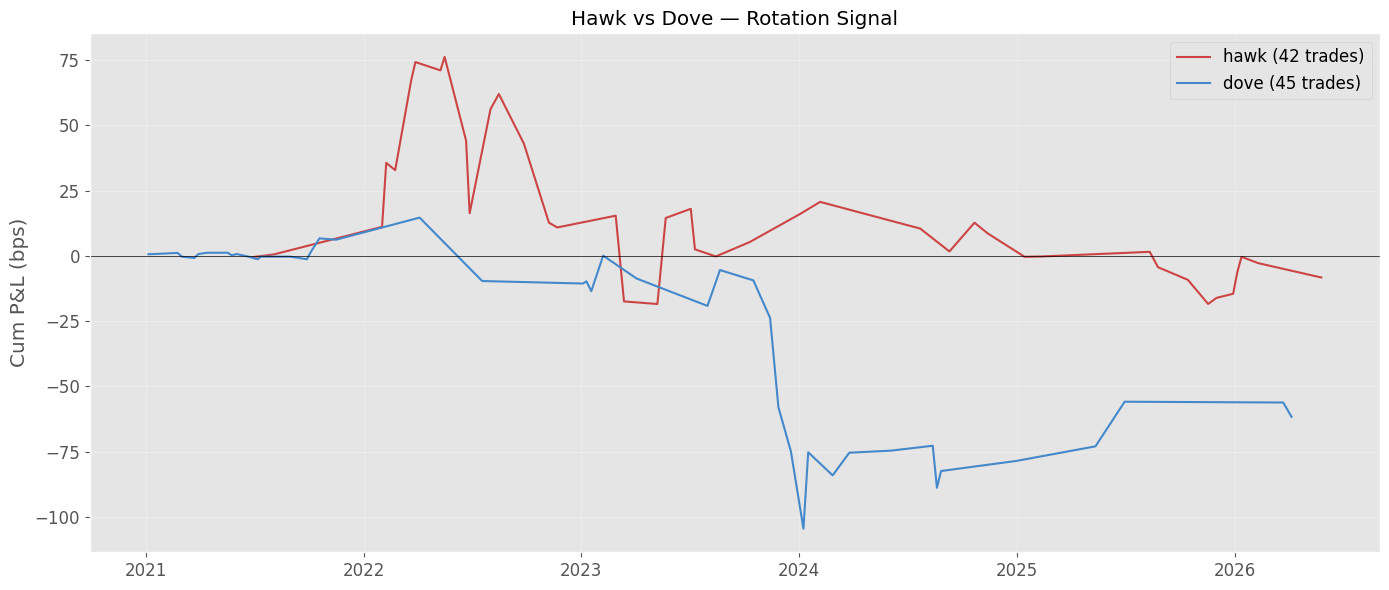

In [9]:
if primary in all_closed:
    cl = all_closed[primary]
    dir_stats = cl.groupby("direction_label").agg(
        trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"))
    display(dir_stats.style.format({
        "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}"}))

    fig, ax = plt.subplots(figsize=(14, 6))
    for lbl, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
        mask = cl["direction_label"] == lbl
        sub = cl[mask].sort_values("opened_at")
        if len(sub) == 0: continue
        ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
                lw=1.5, color=color, label=f"{lbl} ({mask.sum()} trades)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("Cum P&L (bps)"); ax.set_title("Hawk vs Dove — Rotation Signal")
    ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 9. P&L Distribution

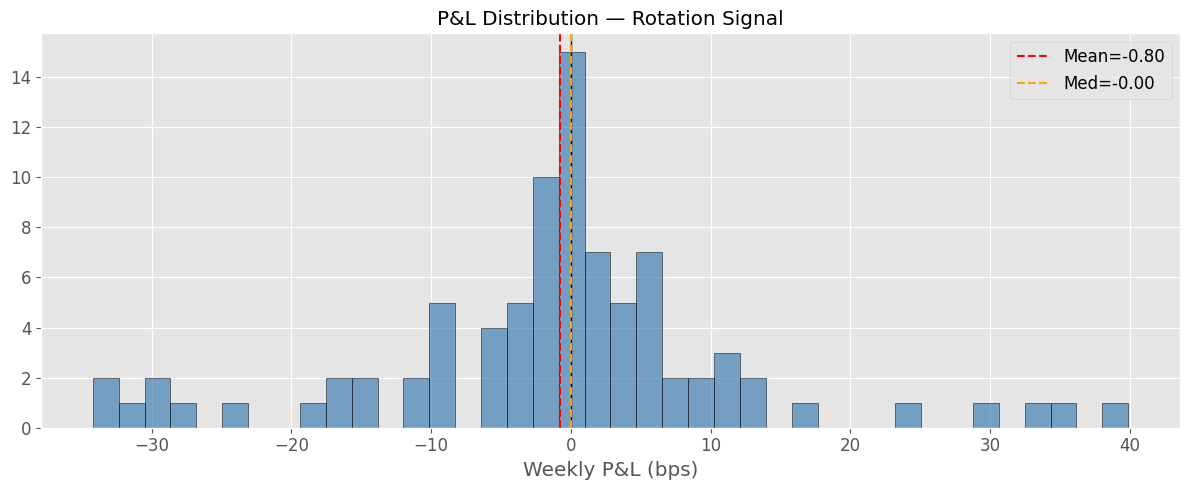

Percentiles:


,Pct,bps
0,1%,-33.03
1,5%,-29.06
2,10%,-16.45
3,25%,-5.15
4,50%,-0.00
5,75%,4.84
6,90%,10.83
7,95%,22.28
8,99%,35.27


In [10]:
if primary in all_closed:
    cl = all_closed[primary]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(cl["pnl_bps"], bins=40, alpha=0.7, color="steelblue", edgecolor="black")
    ax.axvline(0, color="k", lw=1)
    avg, med = cl["pnl_bps"].mean(), cl["pnl_bps"].median()
    ax.axvline(avg, color="red", ls="--", lw=1.5, label=f"Mean={avg:.2f}")
    ax.axvline(med, color="orange", ls="--", lw=1.5, label=f"Med={med:.2f}")
    ax.set_xlabel("Weekly P&L (bps)"); ax.set_title("P&L Distribution — Rotation Signal")
    ax.legend(); plt.tight_layout(); plt.show()

    pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    pct_df = pd.DataFrame({"Pct": [f"{p}%" for p in pcts], "bps": np.percentile(cl["pnl_bps"], pcts)})
    print("Percentiles:")
    display(pct_df.style.format({"bps": "{:.2f}"}))

## 10. Trade Log

In [11]:
if primary in all_closed:
    cl = all_closed[primary]
    log = cl[["opened_at","closed_at","direction_label","hawk_ratio",
              "n_hawks","n_doves","pnl_bps","profitable","cum_bps"]].copy()
    log = log.sort_values("opened_at").reset_index(drop=True)
    display(log.style.format({
        "hawk_ratio": "{:.2f}", "pnl_bps": "{:+.2f}", "cum_bps": "{:+.1f}",
    }).bar(subset=["pnl_bps"], color=["#d65f5f", "#5fba7d"], align="zero"))

,opened_at,closed_at,direction_label,hawk_ratio,n_hawks,n_doves,pnl_bps,profitable,cum_bps
0,2021-01-04 09:30:00-05:00,2021-01-08 16:00:00-05:00,dove,0.00,0,1,+0.60,True,+0.6
1,2021-01-11 09:30:00-05:00,2021-01-15 16:00:00-05:00,dove,0.00,0,3,+0.04,True,+0.6
2,2021-02-22 09:30:00-05:00,2021-02-26 16:00:00-05:00,dove,0.25,1,3,+0.46,True,+1.1
3,2021-03-01 09:30:00-05:00,2021-03-05 16:00:00-05:00,dove,0.00,0,3,-1.43,False,-0.3
4,2021-03-22 09:30:00-04:00,2021-03-26 16:00:00-04:00,dove,0.22,2,7,-0.50,False,-0.8
5,2021-03-29 09:30:00-04:00,2021-04-02 16:00:00-04:00,dove,0.00,0,2,+1.50,True,+0.7
6,2021-04-12 09:30:00-04:00,2021-04-16 16:00:00-04:00,dove,0.00,0,4,+0.50,True,+1.2
7,2021-05-10 09:30:00-04:00,2021-05-14 16:00:00-04:00,dove,0.20,1,4,-0.00,False,+1.2
8,2021-05-17 09:30:00-04:00,2021-05-21 16:00:00-04:00,dove,0.00,0,4,-0.00,False,+1.2
9,2021-05-24 09:30:00-04:00,2021-05-28 16:00:00-04:00,dove,0.00,0,2,-1.00,False,+0.2
